In [ ]:
# PANDAS CONTINUED....
# join()/merge()
"""
types of join in SQL
- inner
- outer
- left
- right
- self join
"""

In [50]:
import pandas as pd
employee1 = pd.DataFrame({
    'empid': [101,102,103,104,105],
    "Name": ["Sunita","Rohit","Dhoni","Kohli","Deepali"],
    "Department": ["HR","Finance","IT","Finance","IT"]
})

salary = pd.DataFrame({
    'empid': [106,107,103,104,110],
    "Salary": [500,650,2300,1250,345],
    "grade": ["A","B","C","D","E"]
})

In [51]:
# this will merge the left side of a dataframe
left_merge = pd.merge(employee1,salary, on = "empid", how = "left")
left_merge

,empid,Name,Department,Salary,grade
0,101,Sunita,HR,NaN,NaN
1,102,Rohit,Finance,NaN,NaN
2,103,Dhoni,IT,2300.0,C
3,104,Kohli,Finance,1250.0,D
4,105,Deepali,IT,NaN,NaN


In [54]:
# this will merge the right side of a dataframe
right_merge = pd.merge(employee1, salary, on = "empid", how = "right")
right_merge

,empid,Name,Department,Salary,grade
0,106,NaN,NaN,500,A
1,107,NaN,NaN,650,B
2,103,Dhoni,IT,2300,C
3,104,Kohli,Finance,1250,D
4,110,NaN,NaN,345,E


In [53]:
# this merge only those rows from both the tables that are having same columns with same data like empid with 103 and 104.
inner_merge = pd.merge(employee1, salary, on = "empid", how = "inner")
inner_merge

,empid,Name,Department,Salary,grade
0,103,Dhoni,IT,2300,C
1,104,Kohli,Finance,1250,D


In [21]:
employee1.isnull().sum()

,0
empid,0
Name,0
Department,0


In [22]:
employee1.duplicated().sum()

np.int64(0)

In [24]:
# MATPLOTLIB
import matplotlib.pyplot as plt
import seaborn as sns

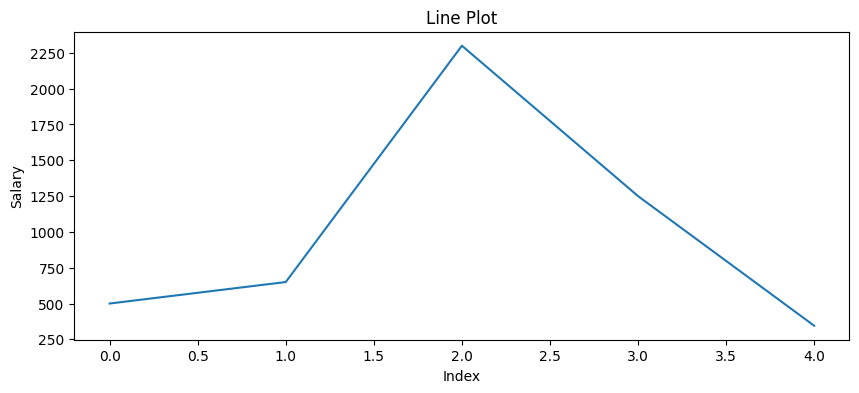

In [56]:
# plot line_graph
plt.figure(figsize = (10,4)) # inches in width and height for the graph
plt.plot(salary.index, salary["Salary"])
plt.title("Line Plot")
plt.xlabel("Index")
plt.ylabel("Salary")
plt.show()

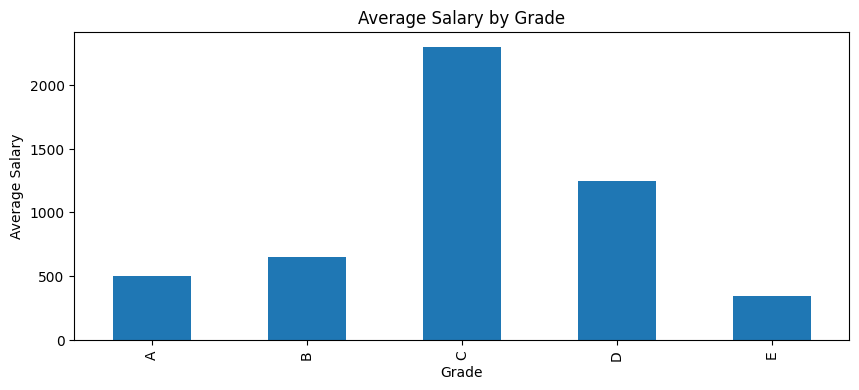

In [33]:
plt.figure(figsize = (10,4))
salary.groupby("grade")["Salary"].mean().plot(kind = "bar") # calculates the average salary for each grade using a bar chart.
plt.title("Average Salary by Grade")
plt.xlabel("Grade")
plt.ylabel("Average Salary")
plt.show()

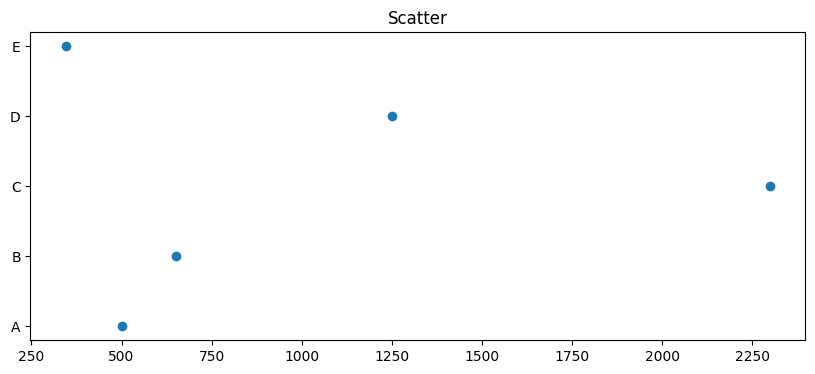

In [34]:
# Scatter plot
# it is plotted in between 2 columns of continuous datatypes.

plt.figure(figsize = (10,4))
plt.scatter(salary["Salary"], salary["grade"])
plt.title("Scatter")
plt.show()

In [38]:
data_set_2008 = pd.read_csv("Most Runs Over - 2008.csv")
data_set_2008.head()

,POS,Player,Runs,BF,SR,4s,6s,Against,Venue,Match Date
0,1,Virender Sehwag,30,6,500.00,3,3,DEC,Rajiv Gandhi Intl. Cricket Stadium,22 April 2008
1,2,Sanath Jayasuriya,26,5,520.00,2,3,CSK,Wankhede Stadium,14 May 2008
2,3,MF Maharoof,26,5,520.00,0,4,RR,Sawai Mansingh Stadium,11 May 2008
3,4,Rohit Sharma,26,6,433.33,3,2,DC,Rajiv Gandhi Intl. Cricket Stadium,22 April 2008
4,5,Shane Watson,26,6,433.33,5,1,RCB,M. Chinnaswamy Stadium,26 April 2008


In [44]:
# make Dict key-> year, value-> path
IPL_Data = {}
for year in range(2008,2022):
  IPL_Data[year] = pd.read_csv(f"Most Runs Over - {year}.csv")

for i,j in IPL_Data.items():
  print(i, "-->",j)

2008 -->      POS                 Player  Runs  BF      SR  4s  6s Against  \
0      1        Virender Sehwag    30   6  500.00   3   3     DEC   
1      2      Sanath Jayasuriya    26   5  520.00   2   3     CSK   
2      3            MF Maharoof    26   5  520.00   0   4      RR   
3      4           Rohit Sharma    26   6  433.33   3   2      DC   
4      5           Shane Watson    26   6  433.33   5   1     RCB   
..   ...                    ...   ...  ..     ...  ..  ..     ...   
145  146         Gautam Gambhir    13   5  260.00   3   0     RCB   
146  147  Subramaniam Badrinath    13   5  260.00   0   2    PBKS   
147  148         Michael Hussey    13   4  325.00   1   1    PBKS   
148  149           Yusuf Pathan    13   4  325.00   3   0    PBKS   
149  150        Stephen Fleming    13   5  260.00   1   1     RCB   

                                  Venue     Match Date  
0    Rajiv Gandhi Intl. Cricket Stadium  22 April 2008  
1                      Wankhede Stadium    14 Ma

In [45]:
for year,df in IPL_Data.items(): # this will add a new column named as Season in the dataset.
  df["Season"] = year

In [47]:
IPL_2008_2021 = pd.concat(IPL_Data.values(),ignore_index = True)
IPL_2008_2021.sample(5)

,POS,Player,Runs,BF,SR,4s,6s,Against,Venue,Match Date,Season
1992,43,Jos Buttler,17,5,340.0,4,0,PBKS,Wankhede Stadium,12 April 2021,2021
678,79,Mahela Jayawardena,15,6,250.0,3,0,MI,Arun Jaitley Stadium,27 April 2012,2012
978,79,Virender Sehwag,15,5,300.0,2,1,SRH,Sharjah Cricket Stadium,22 April 2014,2014
1474,125,Steve Smith,14,4,350.0,0,2,SRH,Maharashtra Cricket Association's Internationa...,22 April 2017,2017
536,87,Brad Hodge,14,5,280.0,2,1,RR,Holkar Cricket Stadium,15 May 2011,2011


In [48]:
IPL_2008_2021.info() # this will show u the datatypes of every column of a dataset.

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2100 entries, 0 to 2099
Data columns (total 11 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   POS         2100 non-null   int64  
 1   Player      2100 non-null   object 
 2   Runs        2100 non-null   int64  
 3   BF          2100 non-null   int64  
 4   SR          2100 non-null   float64
 5   4s          2100 non-null   int64  
 6   6s          2100 non-null   int64  
 7   Against     2100 non-null   object 
 8   Venue       2100 non-null   object 
 9   Match Date  2100 non-null   object 
 10  Season      2100 non-null   int64  
dtypes: float64(1), int64(6), object(4)
memory usage: 180.6+ KB


In [49]:
IPL_2008_2021.shape # this is showing the total rows and columns of a dataset.

(2100, 11)